# Flywheel Data Presentation

This notebook loads the output of the marketing pipeline and presents key metrics.
We use pandas for simplicity but a proper query analytics engine (Snowflake, Redshift, Athena..) would be better for production data using dev/pprd/prod environments.

In [50]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

OUTPUT_DIR = "output/marketing_performance"

In [51]:
def load_partitioned_parquet(base_dir):
    """
    Loads Hive-partitioned parquet files manually if pyarrow discovery fails.
    Restores partition columns (_event_date, _vendor) from the file path.
    """
    if not os.path.exists(base_dir):
        print(f"Directory {base_dir} does not exist.")
        return pd.DataFrame()

    files = glob.glob(os.path.join(base_dir, "**", "*.parquet"), recursive=True)
    if not files:
        print("No files found.")
        return pd.DataFrame()

    print(f"Found {len(files)} files.")
    dfs = []

    for f in files:
        df = pd.read_parquet(f)

        # Restore partitions from path
        # Example path: .../_event_date=2024-01-01/_vendor=vendor_a/part.parquet
        parts = f.split(os.sep)
        for part in parts:
            if part.startswith("_event_date="):
                df["_event_date"] = part.split("=", 1)[1]
            elif part.startswith("_vendor="):
                df["_vendor"] = part.split("=", 1)[1]

        dfs.append(df)

    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


# Load Data
df = load_partitioned_parquet(OUTPUT_DIR)
print(f"Loaded {len(df)} rows.")
df.info()

Found 2 files.
Loaded 15 rows.
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   campaign_id    15 non-null     str                
 1   impressions    15 non-null     int64              
 2   clicks         15 non-null     int64              
 3   spend          15 non-null     float64            
 4   _record_id     15 non-null     str                
 5   _ingestion_at  15 non-null     datetime64[us]     
 6   _event_ts      15 non-null     datetime64[us, UTC]
 7   _is_valid      15 non-null     bool               
 8   _dq_issues     15 non-null     str                
 9   _raw_data      15 non-null     str                
 10  _event_date    15 non-null     str                
 11  _vendor        15 non-null     str                
dtypes: bool(1), datetime64[us, UTC](1), datetime64[us](1), float64(1), int64(2), str(6)
memo

In [52]:
# Validate Columns
if not df.empty:
    print("Columns:", df.columns.tolist())
    print("\nSample Data:")
    print(df.sample(min(5, len(df))))
else:
    print("Warning: DataFrame is empty. Run the pipeline!")

Columns: ['campaign_id', 'impressions', 'clicks', 'spend', '_record_id', '_ingestion_at', '_event_ts', '_is_valid', '_dq_issues', '_raw_data', '_event_date', '_vendor']

Sample Data:
   campaign_id  impressions  clicks   spend                        _record_id              _ingestion_at                 _event_ts  _is_valid        _dq_issues                                          _raw_data _event_date   _vendor
12      ADN007       123456    1234  2100.0  2162d9b787b3daa9c5f770da5a731c74 2026-03-02 13:57:24.137589 2024-01-15 00:00:00+00:00       True                    {"ad_network_id":"ADN007","network_name":"Redd...  2024-01-15  vendor_b
4     camp_004        56000     892   150.0  11f17391f3fca44fb028b57d66512546 2026-03-02 13:57:24.137589 2024-01-15 00:00:00+00:00       True                    {"campaign_id": "camp_004", "campaign_name": "...  2024-01-15  vendor_a
8       ADN004       145000    2345     0.0  112967d827428fc86b2aad989af7e0b3 2026-03-02 13:57:24.137589 2024-01-15 00


Total Spend by Vendor:
_vendor
vendor_b    50912.50
vendor_a    11545.75
Name: spend, dtype: float64


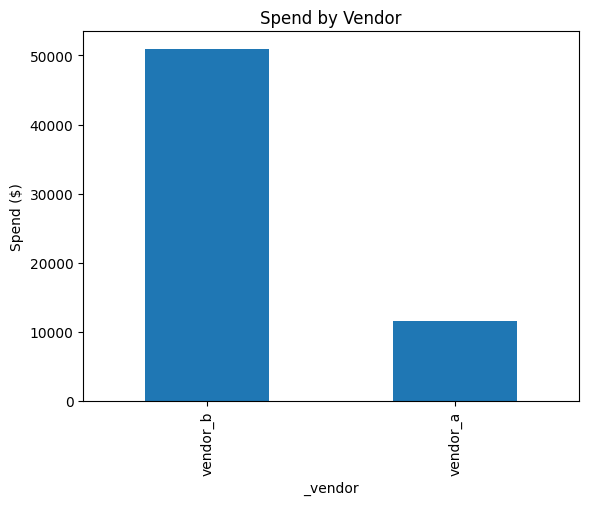


Total Impressions by Vendor:
_vendor
vendor_b    2646360
vendor_a     325350
Name: impressions, dtype: int64


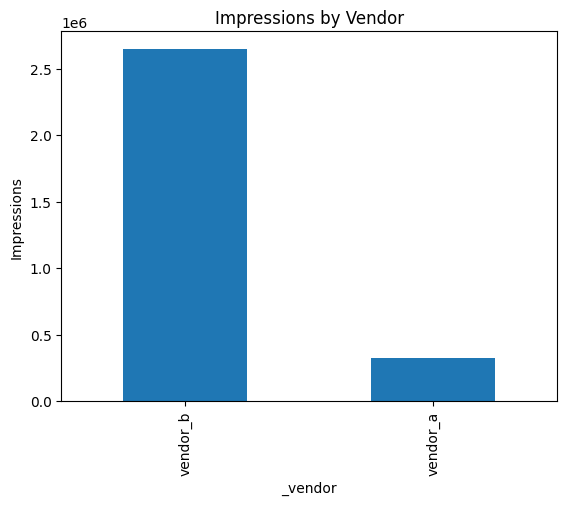


Total Spend by Vendor and Campaign:
_vendor   campaign_id
vendor_b  ADN008         15600.00
          ADN001          8750.25
          ADN006          7890.75
          ADN009          6750.50
vendor_a  camp_001        5420.50
vendor_b  ADN002          5420.50
vendor_a  camp_002        3875.25
vendor_b  ADN003          3200.00
vendor_a  camp_003        2100.00
vendor_b  ADN007          2100.00
          ADN005          1200.50
vendor_a  camp_004         150.00
vendor_b  ADN004             0.00
Name: spend, dtype: float64


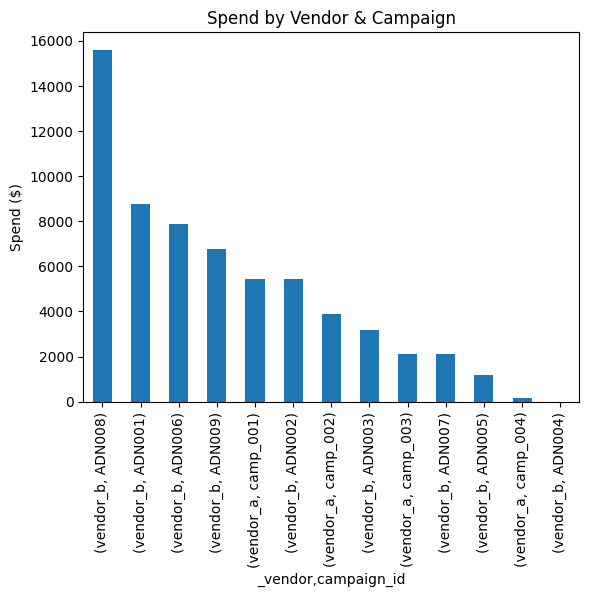

In [53]:
# --- ANALYSIS ---

if not df.empty:
    valid_df = df[df["_is_valid"]].copy()

    # Simple Aggregation: Spend by Vendor
    spend = valid_df.groupby("_vendor")["spend"].sum().sort_values(ascending=False)

    print("\nTotal Spend by Vendor:")
    print(spend)

    if not spend.empty:
        spend.plot(kind="bar", title="Spend by Vendor", ylabel="Spend ($)")
        plt.show()

    # Simple Aggregation: Impressions by Vendor
    impressions = (
        valid_df.groupby("_vendor")["impressions"].sum().sort_values(ascending=False)
    )

    print("\nTotal Impressions by Vendor:")
    print(impressions)

    if not impressions.empty:
        impressions.plot(
            kind="bar", title="Impressions by Vendor", ylabel="Impressions"
        )
        plt.show()

    # Aggregation: Spend by Vendor and Campaign
    vendor_campaign_spend = (
        valid_df.groupby(["_vendor", "campaign_id"])["spend"]
        .sum()
        .sort_values(ascending=False)
    )

    print("\nTotal Spend by Vendor and Campaign:")
    print(vendor_campaign_spend)

    if not vendor_campaign_spend.empty:
        vendor_campaign_spend.plot(
            kind="bar", title="Spend by Vendor & Campaign", ylabel="Spend ($)"
        )
        plt.show()

In [54]:
# --- DATA QUALITY ---

print("\nData Quality Summary:")
print(df["_is_valid"].value_counts())

invalid_rows = df[~df["_is_valid"]]
if not invalid_rows.empty:
    print("\nSample Invalid Records:")
    print(invalid_rows[["_vendor", "_dq_issues", "_raw_data"]].head())
else:
    print("\nNo invalid records found. Data is clean!")


Data Quality Summary:
_is_valid
True     13
False     2
Name: count, dtype: int64

Sample Invalid Records:
     _vendor        _dq_issues                                          _raw_data
1   vendor_a  duplicate_record  {"campaign_id": "camp_001", "campaign_name": "...
11  vendor_b  duplicate_record  {"ad_network_id":"ADN001","network_name":"TikT...


In [55]:
# --- ROI ANALYSIS ---

if not valid_df.empty:
    # ROI Proxy: We define 'ROI' here as Clicks per Dollar spent (Efficiency).
    # Higher is better.

    roi_df = valid_df.groupby(["_vendor", "campaign_id"])[["spend", "clicks"]].sum()
    roi_df = roi_df[roi_df["spend"] > 0].copy()

    roi_df["clicks_per_dollar"] = roi_df["clicks"] / roi_df["spend"]
    roi_df["cpc"] = roi_df["spend"] / roi_df["clicks"]  # Cost Per Click

    best_campaign = roi_df.sort_values("clicks_per_dollar", ascending=False).iloc[0]
    best_campaign_name = best_campaign.name  # (Vendor, Campaign) tuple

    print("\n--- ROI Analysis (Efficiency) ---")
    print(f"Top Campaign (Most Clicks/$): {best_campaign_name}")
    print(f"  - Spend:  ${best_campaign['spend']:.2f}")
    print(f"  - Clicks: {int(best_campaign['clicks'])}")
    print(f"  - CPC:    ${best_campaign['cpc']:.2f}")
    print(f"  - Eff:    {best_campaign['clicks_per_dollar']:.2f} clicks/$")

    print("\nTop 5 Campaigns by Efficiency:")
    print(
        roi_df.sort_values("clicks_per_dollar", ascending=False)[
            ["spend", "clicks", "cpc"]
        ].head(5)
    )


--- ROI Analysis (Efficiency) ---
Top Campaign (Most Clicks/$): ('vendor_a', 'camp_004')
  - Spend:  $150.00
  - Clicks: 892
  - CPC:    $0.17
  - Eff:    5.95 clicks/$

Top 5 Campaigns by Efficiency:
                        spend  clicks       cpc
_vendor  campaign_id                           
vendor_a camp_004       150.0     892  0.168161
vendor_b ADN008       15600.0   12345  1.263670
         ADN005        1200.5     890  1.348876
         ADN009        6750.5    4321  1.562254
vendor_a camp_001      5420.5    3450  1.571159
